### Libraries and Imports

In [27]:
import sys
sys.path.append("../src")
print(sys.path)

from system import System
from dynamics import streaming, collision
from observables import system_momentum, system_kinetic

import matplotlib.pyplot as plt
import numpy as np

['/usr/lib64/python314.zip', '/usr/lib64/python3.14', '/usr/lib64/python3.14/lib-dynload', '', '/home/olegoniy/Desktop/MPC_Project/lib64/python3.14/site-packages', '/home/olegoniy/Desktop/MPC_Project/lib/python3.14/site-packages', '../src', '../src', '../src']


### System Settings 
#### Solvent

In [28]:
system = System(
    N = 50000, 
    box = [5, 5, 5], 
    a = 1.0, 
    h = 0.1, 
    m = 1.0, 
    kBT = 1.0, 
    alpha_deg=30, 
    seed=1      
    )

### Velocity distribution of solvent particles 
___IMPORTANT!___(I think): Here we observe only 1st component (i.e. x-Direction), not the absolute value of velosities

In [29]:
def velocityDistr(system):

    for i in range(1000):
        streaming(system)
        collision(system)

    vx = system.v[:, 0]

    sigma = np.sqrt(system.kBT / system.m)

    x = np.linspace(vx.min(), vx.max(), 300)

    pdf = (
        1 / (np.sqrt(2 * np.pi) * sigma)
        * np.exp(-x**2 / (2 * sigma**2))
    )

    plt.hist(vx, bins=200, density=True, alpha=0.6, label="Simulation")
    plt.plot(x, pdf, label="Maxwell-Boltzmann")

    plt.xlabel(r"$v_x$")
    plt.ylabel(r"$P(v_x)$")
    plt.legend()
    plt.tight_layout()
    plt.show()


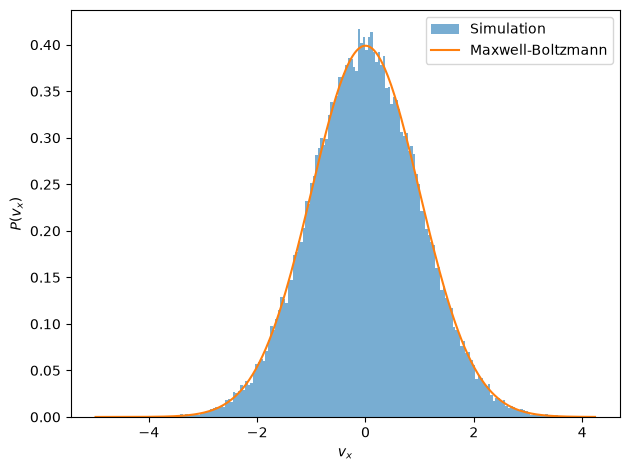

In [30]:
velocityDistr(system)

Here also Gaussian, cause there's no multiplication factor of $v^2$, so probably what was meant in the book

In [31]:
def velocityMagnitudeDistr(system):
    for i in range(1000):
        streaming(system)
        collision(system)

    v_abs = np.sqrt(np.sum(system.v**2, axis=1))

    sigma = np.sqrt(system.kBT / system.m)

    x = np.linspace(v_abs.min(), v_abs.max(), 300)

    pdf = (
        4*np.pi*(1/(2*np.pi*sigma)**(3.0/2))*x**2*np.exp(-x**2/(2*sigma))
    )
    # Since v_abs is a square, the actual values are roots
    plt.hist(v_abs, bins=200, density=True, alpha=0.6, label="Simulation")
    plt.plot(x, pdf, label="Maxwell-Boltzmann")

    plt.xlabel(r"$v_x$")
    plt.ylabel(r"$P(v_x)$")
    plt.legend()
    plt.tight_layout()
    plt.show()

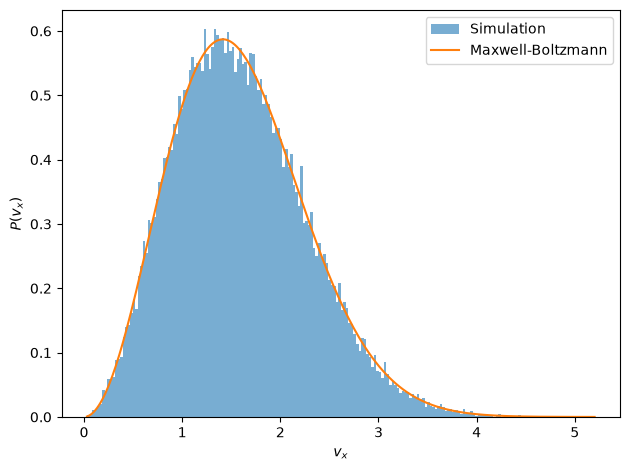

In [32]:
velocityMagnitudeDistr(system)